In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np  # Thêm thư viện numpy để tính log

In [2]:
df = pd.read_json('../../data/raw_concat/tobacco.json')
indicators = df['IndicatorCode'].unique().tolist()
print(indicators)
df

['M_Est_tob_curr_std', 'M_Est_tob_curr_users', 'TOBACCO_MPOWER_OVERVIEW']


,ParentLocationCode,SpatialDim,Value,NumericValue,TimeDimensionBegin,TimeDimensionEnd,TimeDimensionValue,TimeDimType,TimeDim,IndicatorCode
0,AFR,SEN,10.2 [7.8-12.5],10.2,2024-01-01T00:00:00+01:00,2024-12-31T00:00:00+01:00,2024,YEAR,2024,M_Est_tob_curr_std
1,EUR,SVK,23.7 [18.7-28.7],23.7,2015-01-01T00:00:00+01:00,2015-12-31T00:00:00+01:00,2015,YEAR,2015,M_Est_tob_curr_std
2,AMR,BRA,12.5 [9.1-15.9],12.5,2022-01-01T00:00:00+01:00,2022-12-31T00:00:00+01:00,2022,YEAR,2022,M_Est_tob_curr_std
3,EMR,OMN,14.2 [11.0-17.4],14.2,2000-01-01T00:00:00+01:00,2000-12-31T00:00:00+01:00,2000,YEAR,2000,M_Est_tob_curr_std
4,WPR,PLW,14.0 [8.9-19.1],14.0,2007-01-01T00:00:00+01:00,2007-12-31T00:00:00+01:00,2007,YEAR,2007,M_Est_tob_curr_std
...,...,...,...,...,...,...,...,...,...,...
25096,WPR,JPN,2,2.0,2012-01-01T00:00:00+01:00,2012-12-31T00:00:00+01:00,2012,YEAR,2012,TOBACCO_MPOWER_OVERVIEW
25097,EMR,JOR,5,5.0,2012-01-01T00:00:00+01:00,2012-12-31T00:00:00+01:00,2012,YEAR,2012,TOBACCO_MPOWER_OVERVIEW
25098,AFR,GNQ,3,3.0,2012-01-01T00:00:00+01:00,2012-12-31T00:00:00+01:00,2012,YEAR,2012,TOBACCO_MPOWER_OVERVIEW
25099,EUR,NLD,4,4.0,2012-01-01T00:00:00+01:00,2012-12-31T00:00:00+01:00,2012,YEAR,2012,TOBACCO_MPOWER_OVERVIEW


In [3]:
# remove null value
print(len(df))
df=df.dropna(subset=['NumericValue'])
print(len(df))
print(df["NumericValue"].isnull().sum())

25101
24695
0


In [4]:
df_pivot = df[df['IndicatorCode'].isin(indicators)] \
    .pivot_table(
        index=['SpatialDim'],
        columns='IndicatorCode',
        values='NumericValue'
    )

corr_matrix = df_pivot.corr()


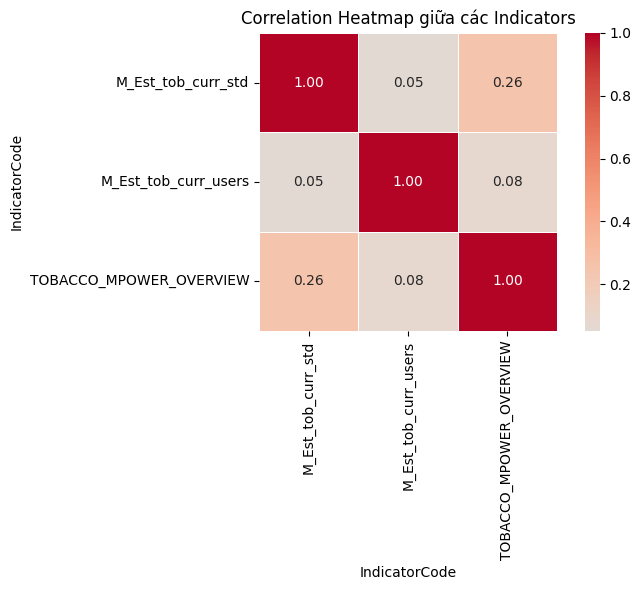

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,          # hiện hệ số corr
    fmt=".2f",
    cmap="coolwarm",
    center=0,            # lấy 0 làm trung tâm
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap giữa các Indicators")
plt.tight_layout()
plt.show()


In [6]:
countries = df["SpatialDim"].unique()
times = pd.to_datetime(df["TimeDim"], format="ISO8601", utc=True)
length, len_countries = len(df), len(countries)
min_date, max_date = times.min().year, times.max().year

print(f"Bộ tobacco có {length} mẫu, thu thập từ {len_countries} quốc gia, trong khoảng thời gian từ {min_date} đến {max_date}!")

Bộ tobacco có 24695 mẫu, thu thập từ 202 quốc gia, trong khoảng thời gian từ 2000 đến 2030!


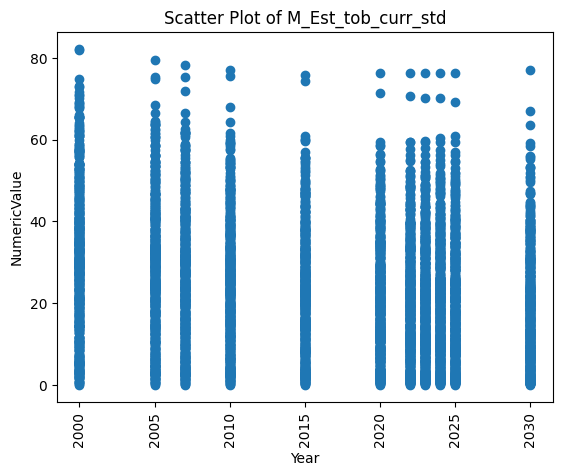

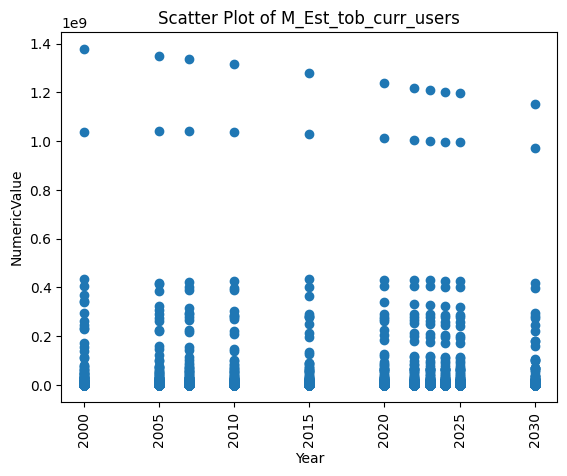

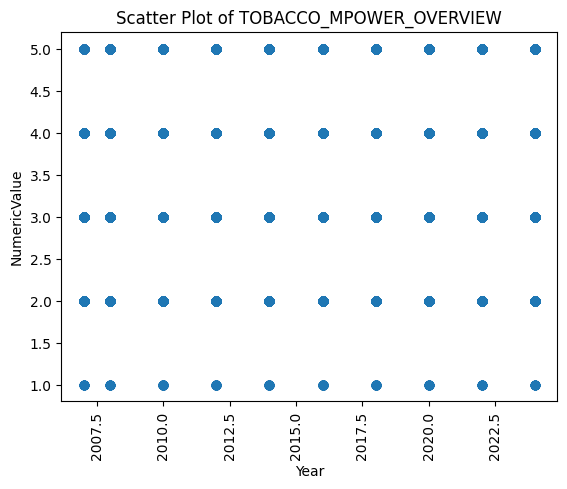

In [7]:
for indicator in indicators:
    df_tmp = df[df["IndicatorCode"]==indicator]
    plt.figure()
    plt.scatter(df_tmp['TimeDim'], df_tmp['NumericValue'])
    plt.xlabel('Year')
    plt.ylabel('NumericValue')
    plt.title(f'Scatter Plot of {indicator}')
    plt.xticks(rotation=90)
    plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_12408\3881616122.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=codes)


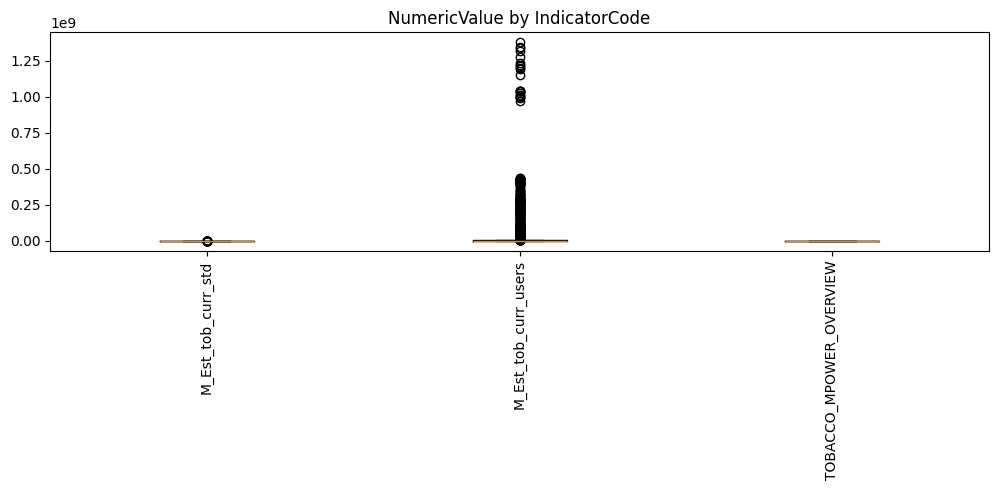

In [8]:
plt.figure(figsize=(10,5))

codes = df['IndicatorCode'].unique()
data = [df[df['IndicatorCode'] == c]['NumericValue'] for c in codes]

plt.boxplot(data, labels=codes)
plt.xticks(rotation=90)
plt.title('NumericValue by IndicatorCode')
plt.tight_layout()
plt.show()


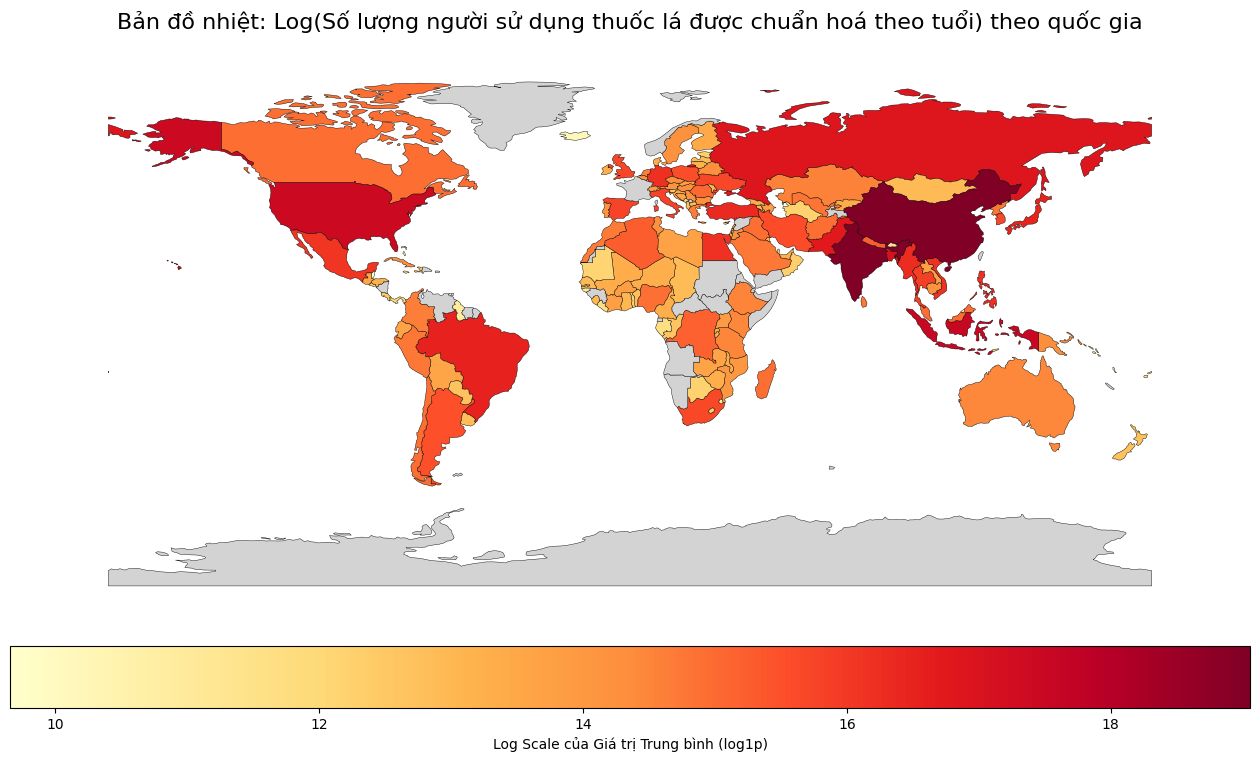

In [9]:
# ==============================
# 1. KIỂM TRA & CHUẨN HÓA (Đã sửa lỗi Mixed Timezones)
# ==============================
df1 = df[df["IndicatorCode"]=="M_Est_tob_curr_users"]

df1["NumericValue"] = pd.to_numeric(df1["NumericValue"], errors="coerce")

# Thêm utc=True để xử lý các múi giờ khác nhau
#df["Date"] = pd.to_datetime(df["Date"], errors="coerce", utc=True)

# ==============================
# 2. GỘP DỮ LIỆU & TÍNH LOG
# ==============================
df_grouped = (
    df1.groupby(
        ["SpatialDim", "ParentLocationCode"],
        as_index=False
    )
    .agg(
        MeanValue=("NumericValue", "mean"),
        Count=("NumericValue", "count")
    )
)

# Tạo cột LogMeanValue: log1p(x) = log(1 + x)
# Việc cộng 1 giúp tránh lỗi nếu MeanValue bằng 0
df_grouped["LogMeanValue"] = np.log1p(df_grouped["MeanValue"])

# ==============================
# 3. LOAD BẢN ĐỒ & MERGE
# ==============================
world = gpd.read_file("../../worldmap/ne_110m_admin_0_countries.shp")

gdf = world.merge(
    df_grouped,
    how="left",
    left_on="ISO_A3",
    right_on="SpatialDim"
)

# ==============================
# 4. VẼ BẢN ĐỒ VỚI THANG LOG
# ==============================
fig, ax = plt.subplots(figsize=(16, 9))

# Sử dụng cột "LogMeanValue" để vẽ màu
gdf.plot(
    column="LogMeanValue", 
    ax=ax,
    legend=True,
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.3,
    legend_kwds={
        'label': "Log Scale của Giá trị Trung bình (log1p)",
        'orientation': "horizontal",
        'pad': 0.05
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

ax.set_title(
    "Bản đồ nhiệt: Log(Số lượng người sử dụng thuốc lá được chuẩn hoá theo tuổi) theo quốc gia", 
    fontsize=16, 
    pad=20
)

ax.axis("off")
plt.show()